In [1]:
import torch
import pandas as pd
import numpy as np
import seaborn as sns

In [4]:
df = pd.read_csv("diabetes.csv")

In [5]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

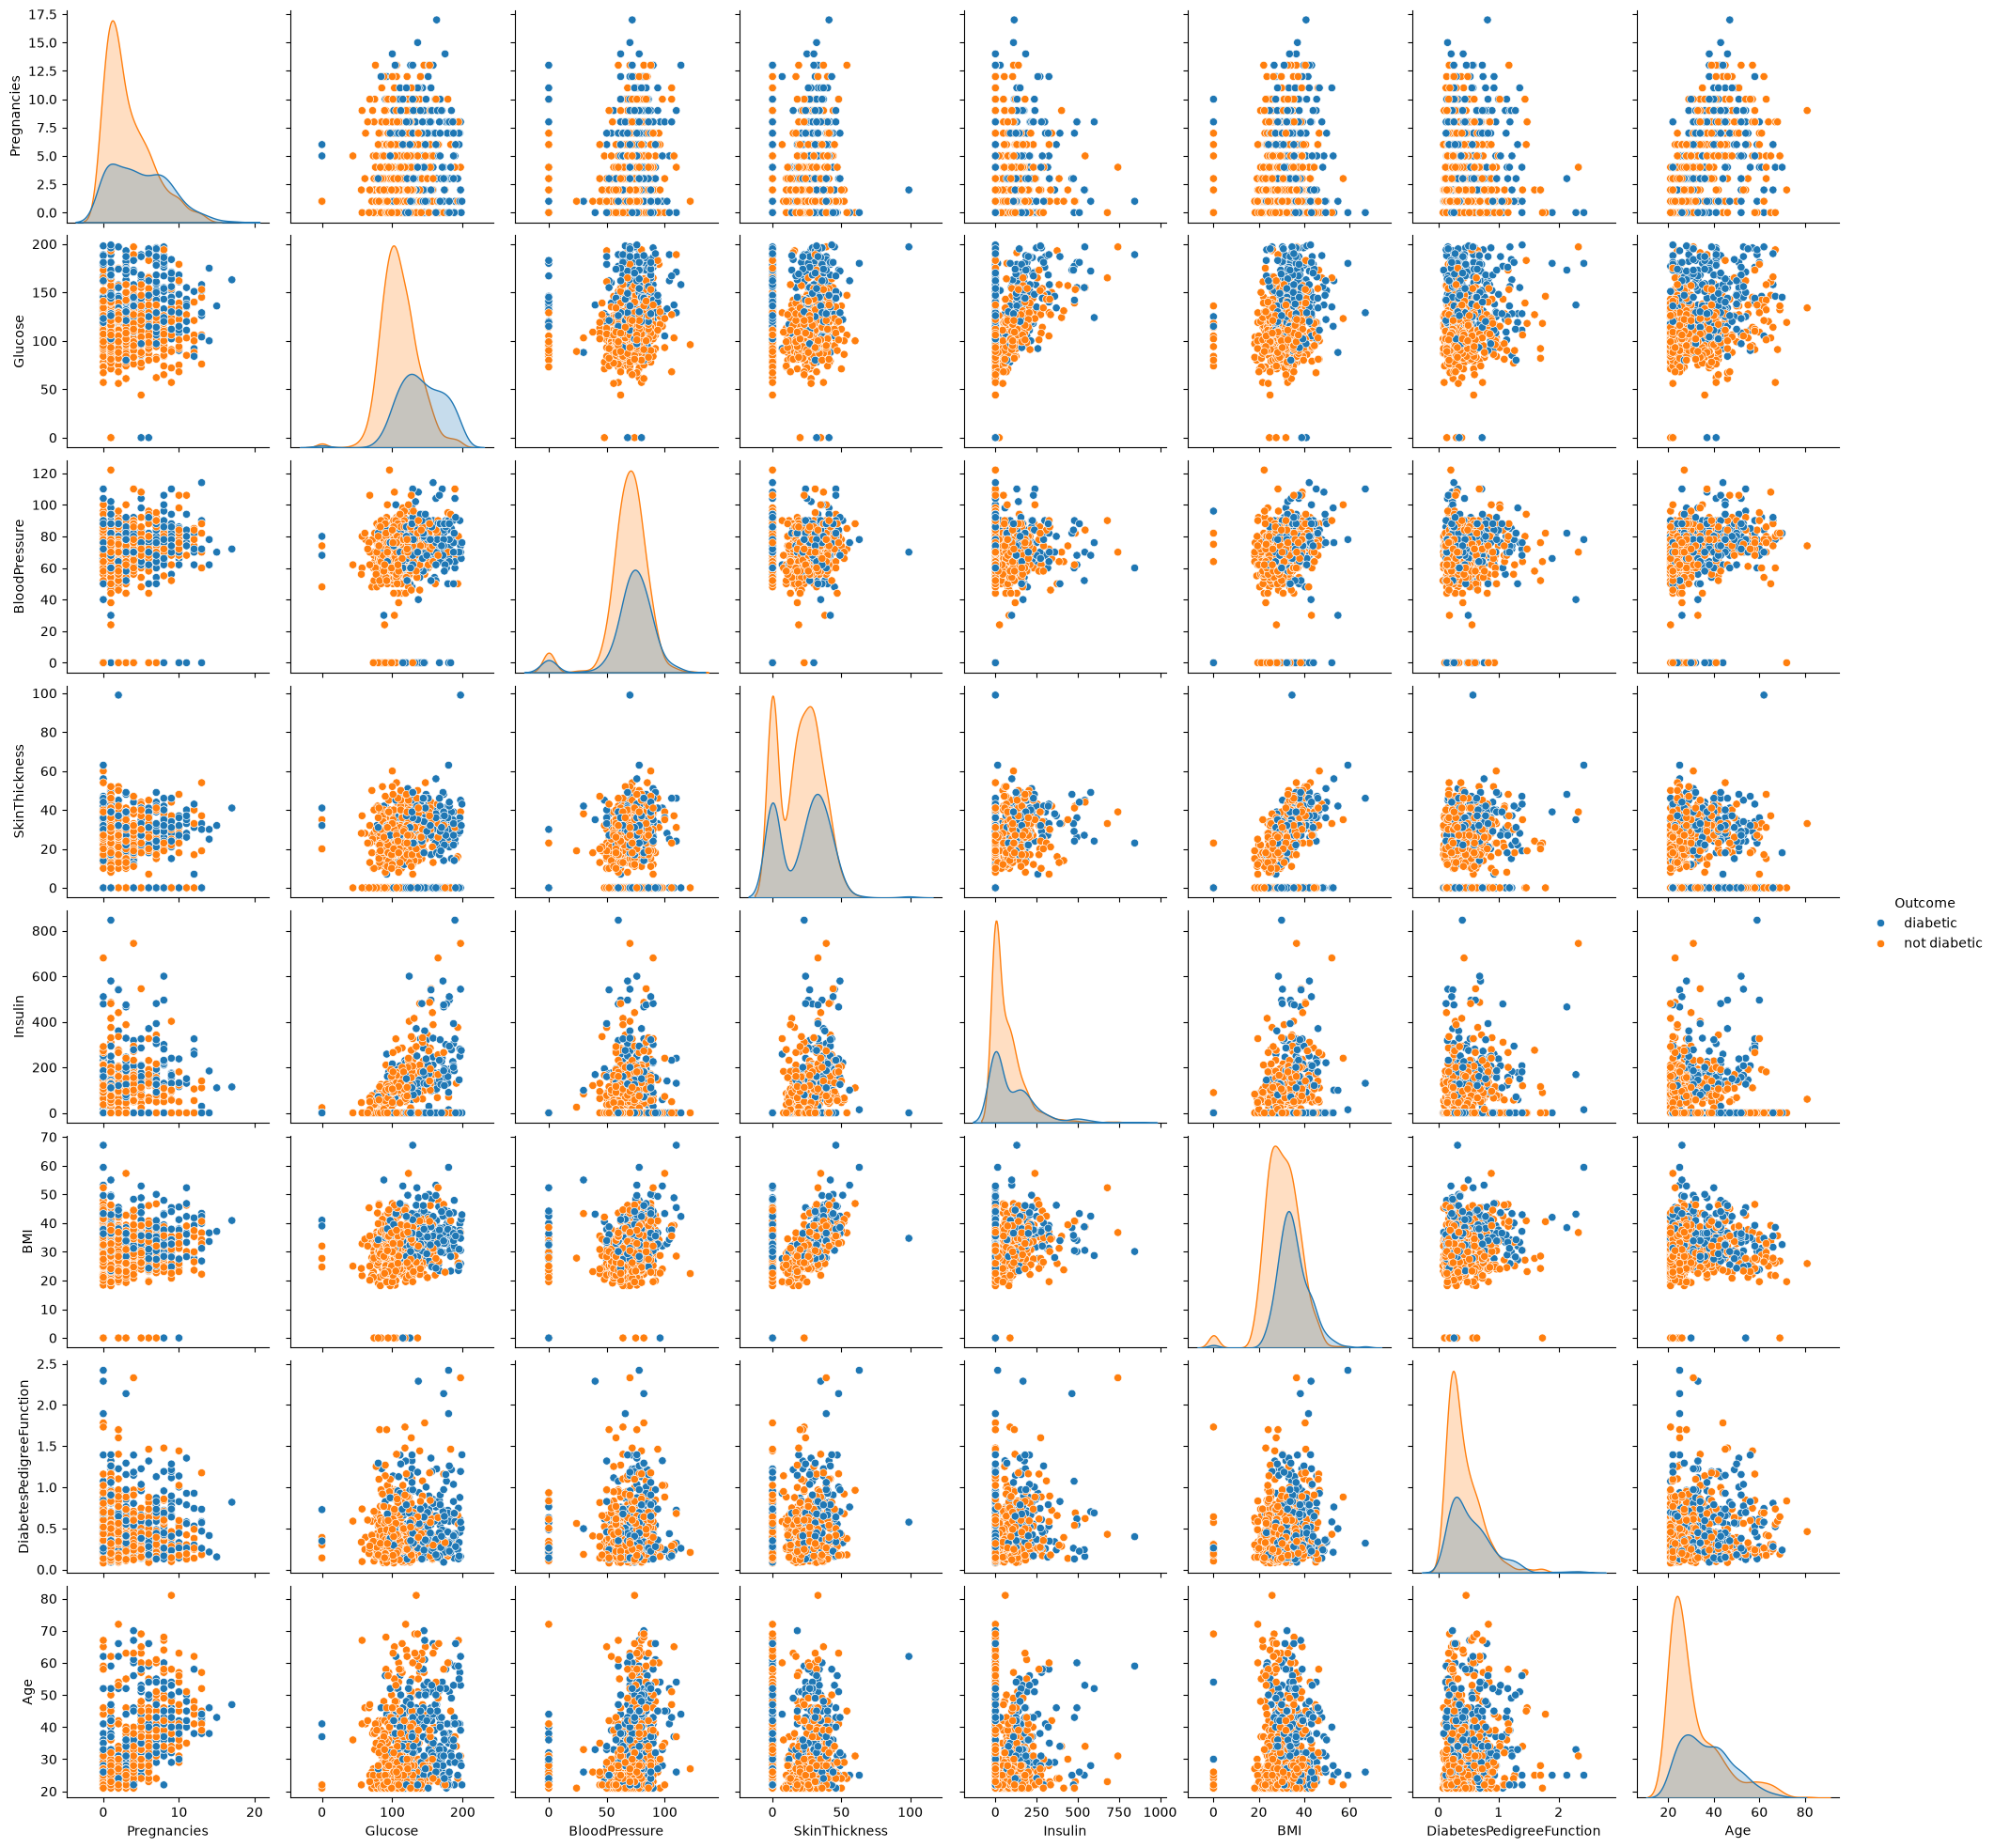

In [9]:
df['Outcome'] = np.where(df['Outcome']==1,"diabetic","not diabetic")
sns.pairplot(df,hue="Outcome")

In [2]:
df = pd.read_csv("diabetes.csv")

In [3]:
from sklearn.model_selection import train_test_split
X = df.drop('Outcome',axis=1).values
y = df['Outcome'].values
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2, random_state=0)

In [4]:
#ann usinng pytorch
import torch
import torch.nn as nn
import torch.nn.functional as F

In [5]:
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)

y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

In [6]:
##model building
class ANN_Model(nn.Module):
    def __init__(self, input_features = 8, hidden1=20, hidden2=20, out_feature=2):
        super().__init__()
        self.f_connected1 = nn.Linear(input_features,hidden1)
        self.f_connected2 = nn.Linear(hidden1,hidden2)
        self.outcome = nn.Linear(hidden2,out_feature)
        

    def forward(self,tracker):
        tracker = F.relu(self.f_connected1(tracker))
        tracker = F.relu(self.f_connected2(tracker))
        tracker = self.outcome(tracker)
        return tracker
    

In [7]:
##intrantiate the model
torch.manual_seed(20) #for random weight distrbutiion 
model = ANN_Model()

In [8]:
model.parameters

<bound method Module.parameters of ANN_Model(
  (f_connected1): Linear(in_features=8, out_features=20, bias=True)
  (f_connected2): Linear(in_features=20, out_features=20, bias=True)
  (outcome): Linear(in_features=20, out_features=2, bias=True)
)>

In [12]:
##backward propagartion
#define loss, optimizer for weight updation
loss_funtion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr =0.01)


In [23]:
epoch = 50
loss_values = []

for i in range(epoch):
    y_pred = model(X_train)  # or can use model.forward(X_train)
    loss = loss_funtion(y_pred, y_train)
    loss_values.append(loss.item())
    if i%10==1:
        print(f"Epoch {i} * loss: {loss.item()}")
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

Epoch 1 * loss: 0.48588213324546814
Epoch 11 * loss: 0.46590760350227356
Epoch 21 * loss: 0.4620317220687866
Epoch 31 * loss: 0.4596438407897949
Epoch 41 * loss: 0.44920504093170166


In [24]:
#plot the loss
import matplotlib.pyplot as plt
%matplotlib inline

Text(0.5, 0, 'epoch')

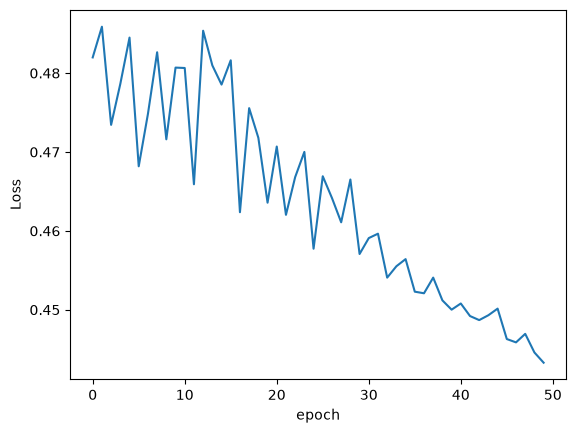

In [26]:
#clean_losses = [loss.item() for loss in loss_values]

plt.plot(range(epoch), loss_values)
plt.ylabel("Loss")
plt.xlabel("epoch")

In [27]:
#pred on X_test
pred = []
with torch.no_grad():
    for i, data in enumerate(X_test):
        y_pred = model(data)
        print(y_pred.argmax().item())
        pred.append(y_pred.argmax().item())



1
0
0
0
0
0
1
1
0
0
1
1
0
1
0
0
1
0
0
0
1
0
1
0
0
1
0
1
0
0
0
0
0
1
0
1
0
0
1
1
0
0
0
1
1
0
0
0
1
0
1
0
1
0
0
1
0
0
0
0
0
0
0
1
1
1
1
0
1
0
0
0
0
1
1
0
0
1
0
0
0
0
0
0
0
0
1
1
1
0
0
0
0
0
0
1
0
0
1
0
0
0
0
0
1
1
0
1
0
1
0
1
1
0
0
1
0
1
0
1
0
0
0
0
0
0
0
0
0
0
1
0
0
0
0
1
1
0
1
1
0
1
0
0
1
0
0
0
0
1
0
0
0
0


In [28]:
pred

[1,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0]

In [29]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,pred)

In [30]:
cm

array([[86, 21],
       [17, 30]])

<Axes: >

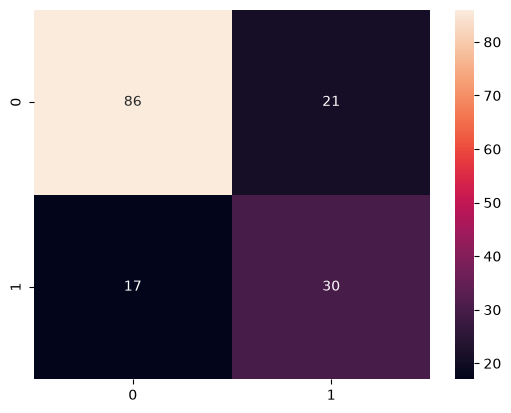

In [31]:
sns.heatmap(cm,annot=True)

In [32]:
from sklearn.metrics import accuracy_score
score = accuracy_score(y_test,pred)

In [33]:
score

0.7532467532467533

In [34]:
#saving the model
torch.save(model,"test_model.pt")

In [ ]:
#load_model
test_model = torch.load("test_model.pt",weights_only=False)

UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL __main__.ANN_Model was not an allowed global by default. Please use `torch.serialization.add_safe_globals([__main__.ANN_Model])` or the `torch.serialization.safe_globals([__main__.ANN_Model])` context manager to allowlist this global if you trust this class/function.

Check the documentation of torch.load to learn more about types accepted by defa

In [37]:
model.eval()

ANN_Model(
  (f_connected1): Linear(in_features=8, out_features=20, bias=True)
  (f_connected2): Linear(in_features=20, out_features=20, bias=True)
  (outcome): Linear(in_features=20, out_features=2, bias=True)
)

In [38]:
#pred on new data
data = [6.8, 123.34, 32.3, 67.3, 0.0, 34.5, 78.4,235.0]
data = torch.tensor(data)
pred_val = test_model(data)
print(pred_val.argmax().item())

1
